# Inferencia estadística vs Aprendizaje de máquinas

### Parte 1: Ajuste de recta 

(Adaptado de  Viviana Acquaviva (2023))

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [3]:
#parámetros para generar figuras de alta calidad
font = {'size'   : 10}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=10) 
matplotlib.rc('ytick', labelsize=10) 
matplotlib.rcParams.update({'figure.autolayout': False})
matplotlib.rcParams['figure.dpi'] = 150

Generaremos datos que sigan una relación lineal (con ruido) y usaremos una grilla para encontrar el mejor ajuste, sin y con considerar incertezas

In [4]:
np.random.seed(16) #semilla fija para reproducibilidad

x = np.arange(10) 

y = 2*x + 5 + np.random.randn(10) #generamos datos con scatter gausiano

Podemos considerar que los datos corresponden al movimiento de un auto con rapidez constante, donde $x$ es tiempo (en segundos) e $y$ es distancia (en metros)

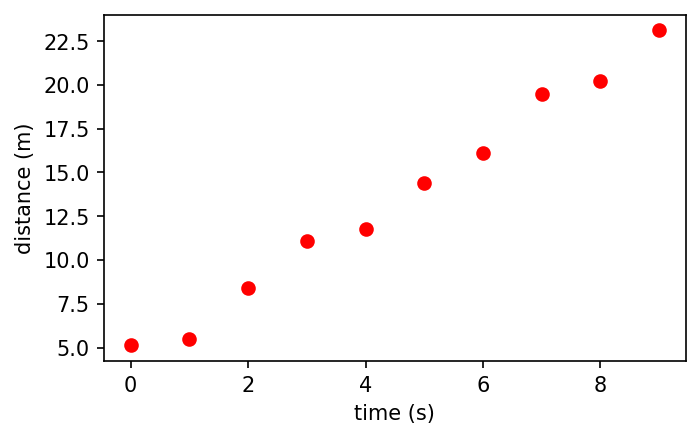

In [5]:
plt.figure(figsize=(5,3)) #
plt.scatter(x,y, c = 'red')
plt.xlabel('time (s)')
plt.ylabel('distance (m)');

In [6]:
x

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [7]:
y = np.round(y,1) #redondeamos los datos

In [8]:
y

array([ 5.1,  5.5,  8.4, 11.1, 11.8, 14.4, 16.1, 19.5, 20.2, 23.1])

Suponga que a partir de esos datos debe ser capaz de decir la distancia a la que estará el auto cuando $t=12$ s. ¿Cómo podemos resolver el problema?

Respuesta: Para resolver el problema es necesario poder saber la pendiente y el intercepto de la recta que mejor se ajusta a estos parametros.

### Inferencia

Ya sabemos que la relación entre distancia y tiempo, para una partícula con rapidez constante está dada por $$d=d_0 +vt$$. Este modelo tienen dos parámetros: $d_0$ u $v$. Necesitamos encontrar estos parámetros para poder usar el modelo y determinar $d(t=12 s)$.


¿Cómo haría esto?




Explique con palabras: Para encontrar estos parametros se deben usar los minimos cuadrados para que la recta se ajuste de mejor manera a los puntos. la funcion "polyfit" de numpy permite encontrar tanto la pendiente como el intercepto de la recta optima a partir de los puntos. 

<details>
<summary>Ayuda!</summary>
Podemos considerar el error en un ajuste de recta como la suma de errores, que consideramos la suma al cuadrado de las distancia entre las distancias predichas por el el modelo ($D^m_i$) y las observadas ($D^o_i$) $$\sum_{i=1}^{10}(D^m(d_0,v,x_i)-D^o_i)^2$$

Encuentre los parámetros de la mejor recta para los datos dados

In [9]:
m, b = np.polyfit(x, y, 1)
print('La pendiente m es : {} y el intercepto b es:  {}' .format(m, b))

La pendiente m es : 2.0484848484848484 y el intercepto b es:  4.301818181818183


In [10]:
def distance(t, m, b):
    d = b + m*t
    return d
d_12 = distance(12, m, b)
print('La distancia recorrida en 12s es: {}' .format(d_12))

La distancia recorrida en 12s es: 28.883636363636363


**Cuáles son los valores de pendiente m e intercepto b encontrado? Con este modelo, cuánto es $d(t=12s)$?**

- **bestm**: 
- **bestb**:

In [11]:
bestm = m
bestb = b
print('Los valores para la pendiente m y el intercepto b encontrados son {} y {} respectivamente.\nUtilizando estos valores, se encontro que d(t=12s) = {}.' .format(bestm, bestb, d_12))

Los valores para la pendiente m y el intercepto b encontrados son 2.0484848484848484 y 4.301818181818183 respectivamente.
Utilizando estos valores, se encontro que d(t=12s) = 28.883636363636363.


Graficamos el mejor ajuste con los datos

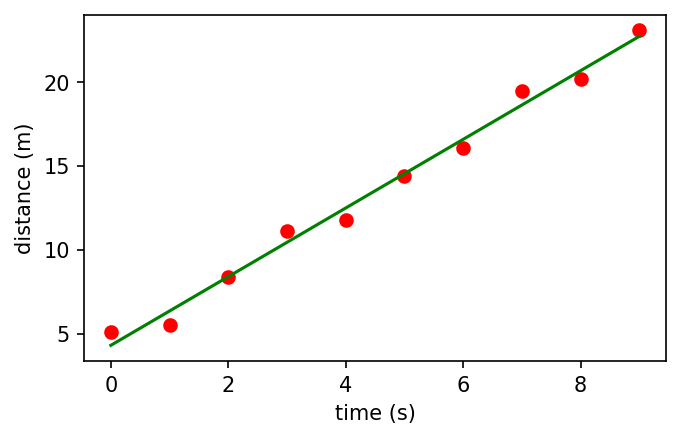

In [12]:
plt.figure(figsize=(5,3))
plt.scatter(x,y, c = 'red')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestm*x+bestb, c = 'g'); #grafique la recta con los mejores parámetros

Y si agregamos incerteza en la medición de distancias?

In [13]:
np.random.seed(10)

dy = np.random.randn(10)*np.sqrt(2) #agregamos incertezas aleatorias, el signo no importa

In [14]:
dy

array([ 1.88314769,  1.01155723, -2.18552605, -0.01185655,  0.87870176,
       -1.01835477,  0.37549009,  0.1535108 ,  0.006069  , -0.24692199])

Text(0, 0.5, 'distance (m)')

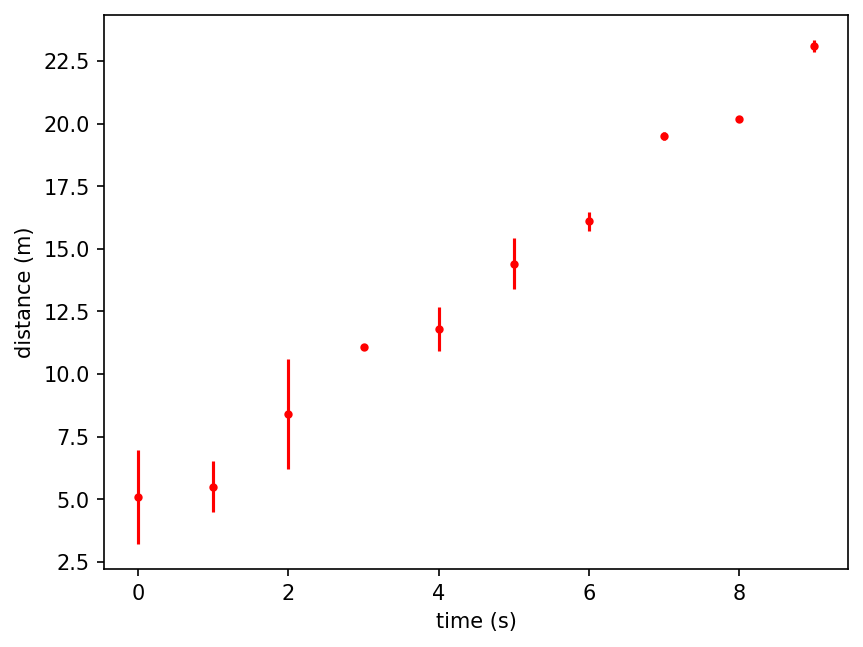

In [15]:
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')

<details>
<summary>Ayuda!</summary>
    Cuando agregamos incertezas, debemos considerar que datos con menor incerteza tienen más "peso". Para esto, modificaremos la función de error cuadrado con el inverso de los cuadrados de las distancias. Esto se conoce como distribución $\chi^2$ (likelihood)


Encuentre los parámetros de la mejor recta cuando agregamos incertezas

Hay una funcion que permite encontrar la recta 

In [16]:
from scipy.optimize import curve_fit
p_opt, p_cov = curve_fit(distance, x, y, sigma = dy)
m_opt, b_opt = p_opt
incertezas = np.sqrt(np.diag(p_cov))
m_cov, b_cov = incertezas

print('La pendiente es {} ± {} y el intercepto es {} ± {}' .format(m_opt, m_cov, b_opt, b_cov))

La pendiente es 1.8204208125912065 ± 0.008391997145983097 y el intercepto es 5.638757975445709 ± 0.060853644718258694


In [17]:
bestb_werr = b_opt
bestm_werr = m_opt

Graficamos los datos con incertezas y el nuevo ajuste

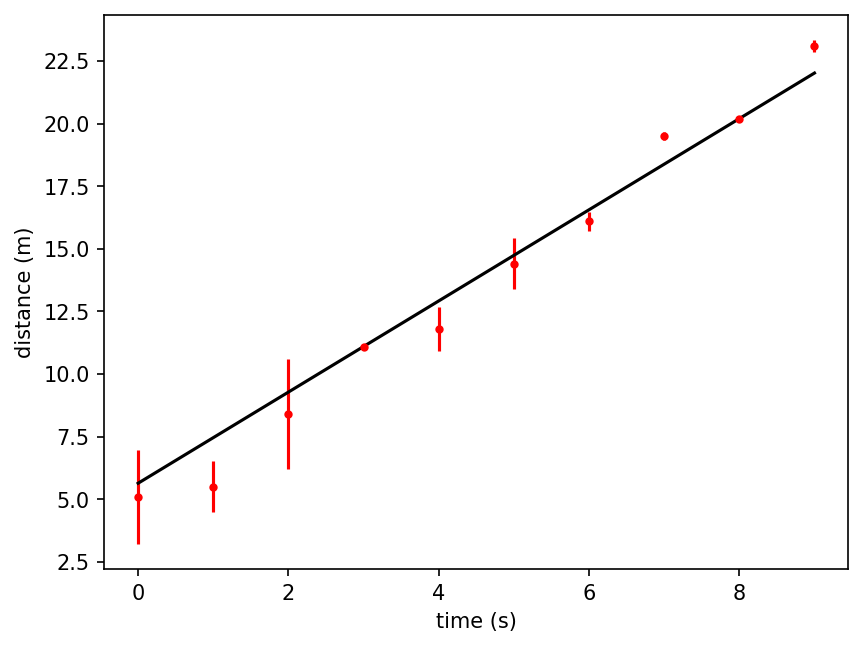

In [18]:
plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.plot(x, bestb_werr + bestm_werr * x, c = 'black') #agregue sus parámetros

Comparemos ambos modelos

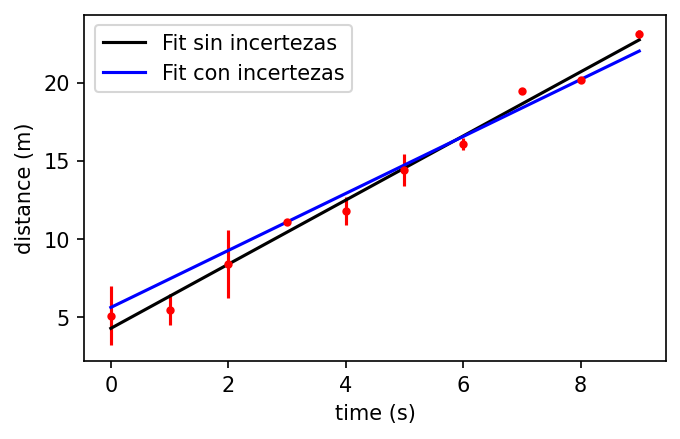

In [19]:
plt.figure(figsize=(5,3))

plt.errorbar(x,y, np.abs(dy), marker = 'o', markersize = 3, c = 'red', linestyle = ' ')

plt.plot(x, bestb + bestm * x, c = 'black', label = 'Fit sin incertezas')

plt.plot(x, bestb_werr + bestm_werr * x, c = 'b', label = 'Fit con incertezas')

plt.xlabel('time (s)')

plt.ylabel('distance (m)')

plt.legend()


**Pregunta: ¿Tiene sentido ese cambio?**

Si tiene sentido ya que no todos los puntos van a tener el mismo peso a la hora de realisar el ajuste. Si un punto tiene mas incertidumbre, es posible que su posicion nos este perjudicando el ajuste por lo que tiene sentido que pese menos. 

In [20]:
d_12_opt = distance(12, bestm_werr, bestb_werr)
print('La distancia utilizando los parametros optimizados es {}' .format(d_12_opt))

La distancia utilizando los parametros optimizados es 27.48380772654019


Calculo de MSE para ambos casos

In [23]:
d_sin = bestm * x + bestb
d_con = bestm_werr * x + bestb_werr

mse_sin = np.mean((y - d_sin)**2)
mse_con = np.mean((y - d_con)**2)

print('El MSE del modelo sin incertidumbre es: {}' .format(mse_sin))
print('El MSE del modelo con incertidumbre es: {}' .format(mse_con))

El MSE del modelo sin incertidumbre es: 0.36420606060606076
El MSE del modelo con incertidumbre es: 0.8898194339980632


### Parte 2: Machine Learning

Si queremos resolver la pregunta de $d(t=12 s)=?$ usando aprendizaje de máquinas, la estrategia no es escribir explícitamente el modelo, ni los parámetros o el likelihood (aunque la elección de modelo sí afecta el resultado y la habilidad de aprender de los datos de entrenamiento).

En este caso, tenemos un problema de aprendizaje supervisado, donde nuestro set de datos inicial son los datos de aprendizaje. Debemos dividir estos datos en un conjunto de entrenamiento y prueba, de forma aleatoria (en el caso de una serie de tiempo esto no es verdad, pero en este caso no importa).

Consideraremos que nuestro problema es de regresión, porque la variable "target" es continua. Probaremos con dos modelos muy simples: Regresión lineal y Árbol de Decisión.

#### Importamos de la librería Sci-kit learn los modelos ya implementados y usaremos funciones de la librería para separar los datos en entrenamiento y prueba a partir de nuestros datos de distancia y tiempo creados al inicio del notebook

In [53]:
from sklearn.tree import DecisionTreeRegressor #modelo de árbol de decisión

In [54]:
from sklearn.linear_model import LinearRegression #modelo de regresión lineal

In [55]:
from sklearn.model_selection import train_test_split  #para dividir los datos

In [56]:
np.random.seed(10) #semilla fija para reproducibilidad

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=3) #crea los sets de entrenamiento/prueba

In [57]:
X_train, y_train #7 datos de entrenamiento

(array([6, 3, 1, 0, 7, 4, 9]),
 array([16.1, 11.1,  5.5,  5.1, 19.5, 11.8, 23.1]))

In [75]:
X_test, y_test # 3 de prueba

(array([8, 2, 5]), array([20.2,  8.4, 14.4]))

In [59]:
treemodel = DecisionTreeRegressor() # Objeto "Estimator" de sklearn, con default params

In [60]:
regmodel = LinearRegression() # Objeto "Estimator" de sklearn, con default params default params

construimos el modelo con los datos de entrenamiento y los usamos para predecir el output en los datos de prueba

In [61]:
#predicciones de datos usando árbol de decisión
y_pred_tree = treemodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

In [62]:
#predicción usando regresión lineal
y_pred_reg = regmodel.fit(X_train.reshape(-1, 1), y_train).predict(X_test.reshape(-1, 1))

In [63]:
print(y_test, y_pred_reg, y_pred_tree) #Real/predicho por RL y AD respectivamente

[20.2  8.4 14.4] [20.89279279  8.41981982 14.65630631] [19.5  5.5 11.8]


Usaremos como métrica de evaluación los errores cuadrados promedio (MSE) para cada modelo

In [64]:
np.mean((y_test-y_pred_reg)**2)

0.18201586721857252

In [65]:
np.mean((y_test-y_pred_tree)**2)

5.22

**Pregunta: ¿Cuál modelo es mejor, RL o AD?**

El mejor modelo es RL ya que tiene una menor MSE. El modelo de AD tiene un mayor MSE indicando que es menos preciso y hay mayor error respeco a los valores reales

Usamos el resultado para predecir $t = 12$ s con cada modelo

In [66]:
print(treemodel.predict(np.array(12).reshape(-1, 1)))
print(regmodel.predict(np.array(12).reshape(-1, 1)))

[23.1]
[29.20810811]


### Conclusión

Finalmente, cuál de las dos estrategias funcionó mejor, inferencia o ML?

- Hubiera funcionado la inferencia estadística si hubiéramos usando un modelo distinto (e.g sinusoidal)?
- En el caso de ML, cómo elegimos el mejor modelo?


**¿Cuál funciona mejor?**
- Mejor para Interpretabilidad: Si el objetivo es entender las relaciones entre variables y poder explicar esas relaciones de manera clara y comprensible, la inferencia estadística puede ser más adecuada. Esto es común en estudios científicos donde la interpretabilidad es clave.

- Mejor para Predicción: Si el objetivo es lograr la mejor precisión predictiva posible, especialmente con datos complejos y de gran escala, los métodos de aprendizaje automático tienden a ser más efectivos. Modelos como árboles de decisión, random forests, y redes neuronales suelen superar a los modelos estadísticos clásicos en tareas predictivas.

- Contexto del Problema: En problemas donde se necesita tanto interpretación como precisión, puede ser útil usar ambos enfoques. Por ejemplo, comenzar con modelos de inferencia para explorar los datos y entender las relaciones básicas, y luego usar ML para optimizar la precisión predictiva.

Respuesta:

El metodo que funciono mejor es el de ML ya que al comparar los MSE se puede ver que el arbol de decisiones tiene un valor de aproximadamente 0.18 mientras que el mejor metodo de inferencia tiene (sin incertidumbre) tiene aproximadamente 0.36

Si hubiesemos usado un modelo distinto si hubiera funcionado para hacer un fit de los datos. Pero al trabajar un comportamiento lineal con un modelo disitnto, este fallaria a la hora de predecir nuevos puntos domo d(t=12)

El mejor modelo de ML se elige comparando los MSE entre ellos. El que tenga menor MSE es mejor para predecir los siguientes puntos.